In [32]:
import pandas as pd
import numpy as np

# loading the dataframe
df = pd.read_parquet("statcast_2026.parquet")

# events is populated only on pitches that end a plate appearance
pa_df = df[df['events'].notna()].copy()

print(f"Total pitches: {len(df):,}")
print(f"Plate appearances (rows with an event): {len(pa_df):,}")
print(f"Unique batters: {df['batter'].nunique()}")
print(pa_df['events'].value_counts())

Total pitches: 538,039
Plate appearances (rows with an event): 138,332
Unique batters: 631
events
field_out                    55715
strikeout                    30447
single                       19492
walk                         11935
double                        5667
home_run                      4209
force_out                     2548
grounded_into_double_play     2360
hit_by_pitch                  1578
sac_fly                        978
field_error                    793
triple                         494
sac_bunt                       491
intent_walk                    396
fielders_choice                312
double_play                    290
truncated_pa                   247
fielders_choice_out            230
strikeout_double_play           73
catcher_interf                  68
sac_fly_double_play              8
triple_play                      1
Name: count, dtype: int64


In [33]:
MIN_PA = 100  # will swap this for a dynamic, season-progress-based calc later

# --- Plate-appearance-level stats (from pa_df) ---

pa_counts = pa_df.groupby('batter').size().rename('pa_count')

k_events = ['strikeout', 'strikeout_double_play']
bb_events = ['walk', 'intent_walk']

batter_stats = pa_df.groupby('batter').agg(
    pa=('events', 'count'),
    k=('events', lambda x: x.isin(k_events).sum()),
    bb=('events', lambda x: x.isin(bb_events).sum()),
).reset_index()

batter_stats['k_rate'] = batter_stats['k'] / batter_stats['pa']
batter_stats['bb_rate'] = batter_stats['bb'] / batter_stats['pa']

# Apply the minimum PA filter
qualified = batter_stats[batter_stats['pa'] >= MIN_PA].copy()

print(f"Batters before filter: {len(batter_stats)}")
print(f"Batters after {MIN_PA}+ PA filter: {len(qualified)}")
qualified.head()

Batters before filter: 631
Batters after 100+ PA filter: 420


,batter,pa,k,bb,k_rate,bb_rate
2,500743,190,19,13,0.100000,0.068421
4,502671,328,79,24,0.240854,0.073171
6,514888,410,82,33,0.200000,0.080488
7,516782,165,39,9,0.236364,0.054545
9,518692,509,82,54,0.161100,0.106090


In [34]:
# Define what counts as a "swing" based on pitch description
swing_descriptions = [
    'foul', 'hit_into_play', 'swinging_strike', 'swinging_strike_blocked',
    'foul_tip', 'foul_bunt', 'missed_bunt'
]
whiff_descriptions = ['swinging_strike', 'swinging_strike_blocked', 'foul_tip']

df['is_swing'] = df['description'].isin(swing_descriptions)
df['is_whiff'] = df['description'].isin(whiff_descriptions)
df['in_zone'] = df['zone'].between(1, 9)
df['out_zone'] = df['zone'].between(11, 14)

# Chase rate: swings on out-of-zone pitches / total out-of-zone pitches seen
# Zone swing rate: swings on in-zone pitches / total in-zone pitches seen
plate_discipline = df.groupby('batter').apply(
    lambda g: pd.Series({
        'chase_rate': g.loc[g['out_zone'], 'is_swing'].mean(),
        'zone_swing_rate': g.loc[g['in_zone'], 'is_swing'].mean(),
        'whiff_rate': g.loc[g['is_swing'], 'is_whiff'].mean(),
    }),
    include_groups=False
).reset_index()

plate_discipline.head()

,batter,chase_rate,zone_swing_rate,whiff_rate
0,457705,0.204545,0.688889,0.325000
1,467793,0.357143,0.680000,0.296296
2,500743,0.314667,0.684039,0.158537
3,502054,0.310345,0.580645,0.370370
4,502671,0.326951,0.642055,0.271268


In [35]:
# Group individual pitch type codes into 3 broad categories,
# matching the fastball/breaking/offspeed split from the project plan
fastball_types = ['FF', 'SI', 'FC']              # four-seam, sinker, cutter
breaking_types = ['SL', 'CU', 'KC', 'ST', 'SV', 'CS']   # slider, curve, knuckle curve, sweeper, slurve, slow curve
offspeed_types = ['CH', 'FS', 'FO', 'SC']         # changeup, splitter, forkball, screwball

def categorize_pitch(pt):
    # Takes a single pitch_type code and returns which bucket it belongs to
    if pt in fastball_types:
        return 'fastball'
    elif pt in breaking_types:
        return 'breaking'
    elif pt in offspeed_types:
        return 'offspeed'
    else:
        return 'other'  # catches rare/unusual pitch types (knuckleball, pitchouts, unclassified, etc.)

# Apply that function to every row, creating a new column with the category
df['pitch_category'] = df['pitch_type'].apply(categorize_pitch)

# Sanity check: see how many pitches landed in each bucket
print(df['pitch_category'].value_counts())

pitch_category
fastball    295242
breaking    161584
offspeed     77600
other         3613
Name: count, dtype: int64


In [36]:
# For each batter, split their swings by pitch category, then find
# what % of swings in each category were whiffs (swing-and-miss).
# We only look at rows where is_swing is True, since whiff rate is
# "of the swings you took, how many missed" -- not "of all pitches."
whiff_by_category = (
    df[df['is_swing']]                                   # keep only pitches the batter swung at
    .groupby(['batter', 'pitch_category'])['is_whiff']    # group by batter AND pitch category together
    .mean()                                                # % of those swings that were whiffs
    .unstack()                                             # pivot pitch_category from rows into columns
    .reset_index()                                         # turn the batter grouping back into a normal column
)

# Rename columns so it's clear these are whiff rates, not just category names
whiff_by_category = whiff_by_category.rename(columns={
    'fastball': 'whiff_rate_fastball',
    'breaking': 'whiff_rate_breaking',
    'offspeed': 'whiff_rate_offspeed',
    'other': 'whiff_rate_other'
})

whiff_by_category = whiff_by_category.drop(columns=['whiff_rate_other'])

whiff_by_category.head()

pitch_category,batter,whiff_rate_breaking,whiff_rate_fastball,whiff_rate_offspeed
0,457705,0.442308,0.241758,0.411765
1,467793,0.666667,0.250000,0.153846
2,500743,0.209877,0.101523,0.306122
3,502054,0.307692,0.416667,0.500000
4,502671,0.269430,0.270893,0.271605


In [37]:
# xwOBA (estimated weighted on-base average) measures contact quality --
# it only has a real value on pitches that were actually put in play,
# so we filter to those before averaging (unlike whiff rate, which needed swings)
contact_df = df[df['estimated_woba_using_speedangle'].notna()].copy()

# Same pattern as whiff_by_category: group by batter AND pitch category,
# average xwOBA within each group, then pivot categories into columns
xwoba_by_category = (
    contact_df
    .groupby(['batter', 'pitch_category'])['estimated_woba_using_speedangle']
    .mean()                      # average xwOBA for that batter against that pitch category
    .unstack()                   # pivot pitch_category from rows into columns
    .reset_index()               # turn batter grouping back into a normal column
)

# Rename columns to be clear these are xwOBA values, not just category names
xwoba_by_category = xwoba_by_category.rename(columns={
    'fastball': 'xwoba_fastball',
    'breaking': 'xwoba_breaking',
    'offspeed': 'xwoba_offspeed',
})

# Drop the 'other' category column again, same reasoning as before --
# tiny, noisy bucket not part of the original 3-category plan
if 'other' in xwoba_by_category.columns:
    xwoba_by_category = xwoba_by_category.drop(columns=['other'])

xwoba_by_category.head()


pitch_category,batter,xwoba_breaking,xwoba_fastball,xwoba_offspeed
0,457705,0.16675,0.284143,0.08875
1,467793,0.0675,0.167606,0.32541
2,500743,0.339885,0.342303,0.20881
3,502054,0.136375,0.143774,0.108
4,502671,0.285097,0.311917,0.321296


In [38]:
# Sanity check 1: does the overall league-wide average match reality?
# Real 2026 league average xwOBA should be roughly .310-.320
print(f"League-wide average xwOBA: {contact_df['estimated_woba_using_speedangle'].mean():.3f}")

# Sanity check 2: how many balls in play is each batter/category average
# actually based on? A "xwoba_breaking" built on 3 balls in play is noisy;
# built on 40 is meaningful.
sample_sizes = (
    contact_df
    .groupby(['batter', 'pitch_category'])
    .size()
    .unstack()
    .rename(columns={
        'fastball': 'n_fastball_bip',
        'breaking': 'n_breaking_bip',
        'offspeed': 'n_offspeed_bip'
    })
)
print(sample_sizes.describe())  # summary stats: min, median, max sample size per category

League-wide average xwOBA: 0.315
pitch_category  n_breaking_bip  n_fastball_bip  n_offspeed_bip       other
count               614.000000      625.000000      604.000000  346.000000
mean                 64.206840      121.524800       34.220199    1.907514
std                  50.393828       93.848793       27.036236    1.224201
min                   1.000000        1.000000        1.000000    1.000000
25%                  19.000000       32.000000       10.000000    1.000000
50%                  56.000000      102.000000       30.000000    2.000000
75%                 102.000000      203.000000       52.000000    2.000000
max                 198.000000      338.000000      121.000000    8.000000


In [39]:
# --- Shrinkage toward league average for xwOBA by pitch category ---
# Instead of trusting each batter's raw average (which is noisy in small
# samples), we blend it with the league-wide average for that category,
# weighted by how many balls in play the batter actually has.
#
# Formula: shrunk_avg = (n * batter_avg + K * league_avg) / (n + K)
# where K = "how many observations worth of trust" we give the league
# average. Higher K = more conservative (pulls harder toward league avg).

K = 20  # treat the league average as equivalent to 20 balls in play of evidence

# League average xwOBA for each pitch category separately (not overall)
league_avg_by_category = contact_df.groupby('pitch_category')['estimated_woba_using_speedangle'].mean()
print("League average xwOBA by category:")
print(league_avg_by_category)

# Merge the raw per-batter averages with their sample sizes so we can
# apply the shrinkage formula row by row
xwoba_shrunk = xwoba_by_category.merge(sample_sizes, on='batter', how='left')

# Apply the shrinkage formula to each category
for cat, col, n_col in [
    ('fastball', 'xwoba_fastball', 'n_fastball_bip'),
    ('breaking', 'xwoba_breaking', 'n_breaking_bip'),
    ('offspeed', 'xwoba_offspeed', 'n_offspeed_bip'),
]:
    league_avg = league_avg_by_category[cat]
    n = xwoba_shrunk[n_col].fillna(0)          # batters with 0 BIP in this category get n=0
    raw_avg = xwoba_shrunk[col].fillna(league_avg)  # if no data at all, start from league avg
    # Blend: weight the batter's own average by their sample size (n),
    # and the league average by K -- more of the batter's own data means
    # their own number counts for more relative to the league prior
    xwoba_shrunk[col + '_shrunk'] = (n * raw_avg + K * league_avg) / (n + K)

xwoba_shrunk[['batter', 'xwoba_fastball_shrunk', 'xwoba_breaking_shrunk', 'xwoba_offspeed_shrunk']].head()

League average xwOBA by category:
pitch_category
breaking     0.28042
fastball     0.34435
offspeed    0.273117
other       0.396317
Name: estimated_woba_using_speedangle, dtype: Float64


pitch_category,batter,xwoba_fastball_shrunk,xwoba_breaking_shrunk,xwoba_offspeed_shrunk
0,457705,0.300198,0.223585,0.22044
1,467793,0.274723,0.231285,0.286674
2,500743,0.342602,0.322649,0.240179
3,502054,0.304235,0.239265,0.265254
4,502671,0.31516,0.284311,0.306696


In [40]:
# Sanity check: the correlation between sample size and how much shrinkage
# moved a value should be negative -- more data (larger n) should mean
# less movement from the raw value toward league average
xwoba_shrunk['fastball_shift'] = (xwoba_shrunk['xwoba_fastball_shrunk'] - xwoba_shrunk['xwoba_fastball'].fillna(0)).abs()
print(xwoba_shrunk[['n_fastball_bip', 'fastball_shift']].corr())

pitch_category  n_fastball_bip  fastball_shift
pitch_category                                
n_fastball_bip         1.00000        -0.46701
fastball_shift        -0.46701         1.00000


In [41]:
# Hard-hit: a ball hit 95+ mph exit velocity is considered "hard-hit"
# by MLB's own definition
contact_df['is_hard_hit'] = contact_df['launch_speed'] >= 95

# Barrel: MLB's official definition -- combines exit velocity AND launch
# angle into "was this struck about as well as possible." The exact
# barrel classification is complex (a sliding scale of angle depending on
# speed), but pybaseball/Statcast already computes this for us in the
# launch_speed_angle column, where a value of 6 specifically means "barrel"
contact_df['is_barrel'] = contact_df['launch_speed_angle'] == 6

# Group by batter, compute each stat
power_stats = contact_df.groupby('batter').agg(
    avg_exit_velo=('launch_speed', 'mean'),      # average speed off the bat
    hard_hit_rate=('is_hard_hit', 'mean'),        # % of batted balls that were hard-hit
    barrel_rate=('is_barrel', 'mean'),            # % of batted balls that were barrels
).reset_index()

power_stats.head()

,batter,avg_exit_velo,hard_hit_rate,barrel_rate
0,457705,87.069231,0.288462,0.057692
1,467793,87.78125,0.4375,0.0
2,500743,86.300649,0.383117,0.058442
3,502054,91.733333,0.333333,0.0
4,502671,86.577477,0.364865,0.103604


In [42]:
# League-wide sanity check across all batters, not just the sample of 5
print(f"League avg exit velo: {power_stats['avg_exit_velo'].mean():.3f}")
print(f"League avg hard-hit rate: {power_stats['hard_hit_rate'].mean():.3f}")
print(f"League avg barrel rate: {power_stats['barrel_rate'].mean():.3f}")

League avg exit velo: 87.577
League avg hard-hit rate: 0.371
League avg barrel rate: 0.072


In [43]:
# GB/FB/LD rate: bb_type already classifies each batted ball as
# ground_ball, fly_ball, line_drive, or popup -- we just need the rate
# of each per batter
batted_ball_type = (
    contact_df.groupby(['batter', 'bb_type'])
    .size()
    .unstack(fill_value=0)   # pivot bb_type into columns; fill_value=0 means "0 of these" not NaN
)

# Convert raw counts into rates (% of a batter's batted balls that were each type)
batted_ball_type = batted_ball_type.div(batted_ball_type.sum(axis=1), axis=0)

# Rename for clarity
batted_ball_type = batted_ball_type.rename(columns={
    'ground_ball': 'gb_rate',
    'fly_ball': 'fb_rate',
    'line_drive': 'ld_rate',
    'popup': 'popup_rate'
}).reset_index()

batted_ball_type.head()

bb_type,batter,fb_rate,gb_rate,ld_rate,popup_rate
0,457705,0.365385,0.365385,0.134615,0.134615
1,467793,0.312500,0.250000,0.187500,0.250000
2,500743,0.207792,0.448052,0.240260,0.103896
3,502054,0.333333,0.500000,0.166667,0.000000
4,502671,0.288288,0.445946,0.193694,0.072072


In [44]:
# League-wide sanity check
print(f"League avg GB rate: {batted_ball_type['gb_rate'].mean():.3f}")
print(f"League avg FB rate: {batted_ball_type['fb_rate'].mean():.3f}")
print(f"League avg LD rate: {batted_ball_type['ld_rate'].mean():.3f}")
print(f"League avg popup rate: {batted_ball_type['popup_rate'].mean():.3f}")

League avg GB rate: 0.423
League avg FB rate: 0.269
League avg LD rate: 0.230
League avg popup rate: 0.078


In [45]:
# A small number of batted balls are missing hc_x (no hit coordinate
# recorded) -- can't classify direction without it, so drop those rows
# just for this calculation
direction_df = contact_df[contact_df['hc_x'].notna()].copy()

print(f"Balls in play: {len(contact_df)}")
print(f"Balls in play with a valid hit coordinate: {len(direction_df)}")

field_center = direction_df['hc_x'].median()

def classify_direction(row):
    # For a right-handed batter, pulling the ball means hitting it left
    # (hc_x below center). For a left-handed batter, pulling means hitting
    # it right (hc_x above center) -- the logic flips based on stand.
    if row['stand'] == 'R':
        return 'pull' if row['hc_x'] < field_center else 'oppo'
    else:  # left-handed batter
        return 'pull' if row['hc_x'] > field_center else 'oppo'

direction_df['direction'] = direction_df.apply(classify_direction, axis=1)

direction_rates = (
    direction_df.groupby(['batter', 'direction'])
    .size()
    .unstack(fill_value=0)
)
direction_rates = direction_rates.div(direction_rates.sum(axis=1), axis=0)
direction_rates = direction_rates.rename(columns={'pull': 'pull_rate', 'oppo': 'oppo_rate'}).reset_index()

direction_rates.head()

Balls in play: 136705
Balls in play with a valid hit coordinate: 92626


direction,batter,oppo_rate,pull_rate
0,457705,0.461538,0.538462
1,467793,0.312500,0.687500
2,500743,0.461039,0.538961
3,502054,0.500000,0.500000
4,502671,0.454955,0.545045


In [46]:
# Check whether missing hc_x is random, or concentrated in certain
# situations (like home runs, which leave the field entirely)
missing_hc = contact_df[contact_df['hc_x'].isna()]
present_hc = contact_df[contact_df['hc_x'].notna()]

print("Event breakdown WHERE hc_x is missing:")
print(missing_hc['events'].value_counts(normalize=True).head(10))

print("\nEvent breakdown WHERE hc_x is present:")
print(present_hc['events'].value_counts(normalize=True).head(10))

Event breakdown WHERE hc_x is missing:
events
strikeout                    0.690737
walk                         0.270764
hit_by_pitch                 0.035799
strikeout_double_play        0.001656
home_run                     0.000794
field_out                    0.000113
double                       0.000045
single                       0.000045
grounded_into_double_play    0.000023
fielders_choice              0.000023
Name: proportion, dtype: float64

Event breakdown WHERE hc_x is present:
events
field_out                    0.598191
single                       0.209790
double                       0.061106
home_run                     0.045009
force_out                    0.027185
grounded_into_double_play    0.025338
sac_fly                      0.010559
field_error                  0.008475
triple                       0.005333
fielders_choice              0.003304
Name: proportion, dtype: float64


In [47]:
# CORRECTED: use Statcast's 'type' column, where 'X' specifically means
# "ball put into play" -- this is the reliable, standard way to isolate
# batted balls, unlike filtering on estimated_woba_using_speedangle
# (which turned out to also be populated on some strikeouts/walks)
contact_df = df[df['type'] == 'X'].copy()

print(f"Rows in corrected contact_df: {len(contact_df)}")
print(contact_df['events'].value_counts(normalize=True).head(10))

Rows in corrected contact_df: 93588
events
field_out                    0.595322
single                       0.208275
double                       0.060553
home_run                     0.044974
force_out                    0.027226
grounded_into_double_play    0.025217
sac_fly                      0.010450
field_error                  0.008473
triple                       0.005278
sac_bunt                     0.005246
Name: proportion, dtype: float64


In [48]:
# --- 1. Recompute is_hard_hit / is_barrel (contact_df is a new object now) ---
contact_df['is_hard_hit'] = contact_df['launch_speed'] >= 95
contact_df['is_barrel'] = contact_df['launch_speed_angle'] == 6

# --- 2. xwOBA by pitch category (rebuild raw averages + sample sizes) ---
xwoba_by_category = (
    contact_df
    .groupby(['batter', 'pitch_category'])['estimated_woba_using_speedangle']
    .mean()
    .unstack()
    .reset_index()
    .rename(columns={'fastball': 'xwoba_fastball', 'breaking': 'xwoba_breaking', 'offspeed': 'xwoba_offspeed'})
)
if 'other' in xwoba_by_category.columns:
    xwoba_by_category = xwoba_by_category.drop(columns=['other'])

sample_sizes = (
    contact_df.groupby(['batter', 'pitch_category']).size().unstack()
    .rename(columns={'fastball': 'n_fastball_bip', 'breaking': 'n_breaking_bip', 'offspeed': 'n_offspeed_bip'})
)

league_avg_by_category = contact_df.groupby('pitch_category')['estimated_woba_using_speedangle'].mean()

xwoba_shrunk = xwoba_by_category.merge(sample_sizes, on='batter', how='left')
K = 20
for cat, col, n_col in [
    ('fastball', 'xwoba_fastball', 'n_fastball_bip'),
    ('breaking', 'xwoba_breaking', 'n_breaking_bip'),
    ('offspeed', 'xwoba_offspeed', 'n_offspeed_bip'),
]:
    league_avg = league_avg_by_category[cat]
    n = xwoba_shrunk[n_col].fillna(0)
    raw_avg = xwoba_shrunk[col].fillna(league_avg)
    xwoba_shrunk[col + '_shrunk'] = (n * raw_avg + K * league_avg) / (n + K)

# --- 3. Power stats: exit velo, hard-hit rate, barrel rate ---
power_stats = contact_df.groupby('batter').agg(
    avg_exit_velo=('launch_speed', 'mean'),
    hard_hit_rate=('is_hard_hit', 'mean'),
    barrel_rate=('is_barrel', 'mean'),
).reset_index()

# --- 4. Batted ball type: GB/FB/LD/popup rate ---
batted_ball_type = (
    contact_df.groupby(['batter', 'bb_type']).size().unstack(fill_value=0)
)
batted_ball_type = batted_ball_type.div(batted_ball_type.sum(axis=1), axis=0)
batted_ball_type = batted_ball_type.rename(columns={
    'ground_ball': 'gb_rate', 'fly_ball': 'fb_rate', 'line_drive': 'ld_rate', 'popup': 'popup_rate'
}).reset_index()

# --- 5. Pull/oppo rate ---
direction_df = contact_df[contact_df['hc_x'].notna()].copy()
print(f"Balls in play: {len(contact_df)}")
print(f"Balls in play with valid hit coordinate: {len(direction_df)}")

field_center = direction_df['hc_x'].median()

def classify_direction(row):
    if row['stand'] == 'R':
        return 'pull' if row['hc_x'] < field_center else 'oppo'
    else:
        return 'pull' if row['hc_x'] > field_center else 'oppo'

direction_df['direction'] = direction_df.apply(classify_direction, axis=1)
direction_rates = (
    direction_df.groupby(['batter', 'direction']).size().unstack(fill_value=0)
)
direction_rates = direction_rates.div(direction_rates.sum(axis=1), axis=0)
direction_rates = direction_rates.rename(columns={'pull': 'pull_rate', 'oppo': 'oppo_rate'}).reset_index()

print(f"\nLeague avg exit velo: {power_stats['avg_exit_velo'].mean():.3f}")
print(f"League avg hard-hit rate: {power_stats['hard_hit_rate'].mean():.3f}")
print(f"League avg barrel rate: {power_stats['barrel_rate'].mean():.3f}")

Balls in play: 93588
Balls in play with valid hit coordinate: 93542

League avg exit velo: 87.101
League avg hard-hit rate: 0.368
League avg barrel rate: 0.072


In [49]:
# Start from 'qualified' (409 batters, 100+ PA already filtered) and
# merge every other feature table onto it, one at a time. Using 'left'
# joins throughout so we never lose or duplicate the 409 qualified batters
# -- we're just attaching more columns to each of them.

batter_features = qualified[['batter', 'pa', 'k_rate', 'bb_rate']].copy()

batter_features = batter_features.merge(
    plate_discipline[['batter', 'chase_rate', 'zone_swing_rate', 'whiff_rate']],
    on='batter', how='left'
)

batter_features = batter_features.merge(
    whiff_by_category[['batter', 'whiff_rate_fastball', 'whiff_rate_breaking', 'whiff_rate_offspeed']],
    on='batter', how='left'
)

batter_features = batter_features.merge(
    xwoba_shrunk[['batter', 'xwoba_fastball_shrunk', 'xwoba_breaking_shrunk', 'xwoba_offspeed_shrunk']],
    on='batter', how='left'
)

batter_features = batter_features.merge(
    power_stats[['batter', 'avg_exit_velo', 'hard_hit_rate', 'barrel_rate']],
    on='batter', how='left'
)

batter_features = batter_features.merge(
    batted_ball_type[['batter', 'gb_rate', 'fb_rate', 'ld_rate', 'popup_rate']],
    on='batter', how='left'
)

batter_features = batter_features.merge(
    direction_rates[['batter', 'pull_rate', 'oppo_rate']],
    on='batter', how='left'
)

# Sanity checks: did we keep exactly 409 rows (no accidental duplication
# or row loss from the merges), and how many missing values do we have
# in each column now?
print(f"Shape: {batter_features.shape}")
print(f"\nMissing values per column:")
print(batter_features.isna().sum())

Shape: (420, 22)

Missing values per column:
batter                   0
pa                       0
k_rate                   0
bb_rate                  0
chase_rate               0
zone_swing_rate          0
whiff_rate               0
whiff_rate_fastball      0
whiff_rate_breaking      0
whiff_rate_offspeed      0
xwoba_fastball_shrunk    0
xwoba_breaking_shrunk    0
xwoba_offspeed_shrunk    0
avg_exit_velo            0
hard_hit_rate            0
barrel_rate              0
gb_rate                  0
fb_rate                  0
ld_rate                  0
popup_rate               0
pull_rate                0
oppo_rate                0
dtype: int64


In [50]:
from sklearn.preprocessing import StandardScaler

# Pick the columns that actually go into clustering -- excludes 'batter'
# (an ID, not a stat) and 'pa' (sample size, not a behavioral trait --
# we already used it for filtering, don't want it influencing archetypes)
feature_cols = [
    'k_rate', 'bb_rate', 'chase_rate', 'zone_swing_rate', 'whiff_rate',
    'whiff_rate_fastball', 'whiff_rate_breaking', 'whiff_rate_offspeed',
    'xwoba_fastball_shrunk', 'xwoba_breaking_shrunk', 'xwoba_offspeed_shrunk',
    'avg_exit_velo', 'hard_hit_rate', 'barrel_rate',
    'gb_rate', 'fb_rate', 'ld_rate', 'popup_rate',
    'pull_rate', 'oppo_rate'
]

# StandardScaler converts each column to z-scores: (value - mean) / std_dev
# so every feature has mean=0, std=1 -- putting them all on equal footing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(batter_features[feature_cols])

# Wrap the scaled array back into a labeled dataframe for readability,
# keeping the batter ID alongside it for reference
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df['batter'] = batter_features['batter'].values

# Sanity check: mean should be ~0 and std should be ~1 for every column
print(X_scaled_df[feature_cols].describe().loc[['mean', 'std']].round(3))

      k_rate  bb_rate  chase_rate  zone_swing_rate  whiff_rate  \
mean  -0.000    0.000       0.000            0.000      -0.000   
std    1.001    1.001       1.001            1.001       1.001   

      whiff_rate_fastball  whiff_rate_breaking  whiff_rate_offspeed  \
mean               -0.000                0.000               -0.000   
std                 1.001                1.001                1.001   

      xwoba_fastball_shrunk  xwoba_breaking_shrunk  xwoba_offspeed_shrunk  \
mean                 -0.000                  0.000                  0.000   
std                   1.001                  1.001                  1.001   

      avg_exit_velo  hard_hit_rate  barrel_rate  gb_rate  fb_rate  ld_rate  \
mean          0.000         -0.000        0.000    0.000    0.000    0.000   
std           1.001          1.001        1.001    1.001    1.001    1.001   

      popup_rate  pull_rate  oppo_rate  
mean       0.000      0.000      0.000  
std        1.001      1.001      1.001

In [51]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Try a range of k values and record inertia + silhouette score for each
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    # random_state=42 makes this reproducible -- same result every time we rerun it
    # n_init=10 runs k-means 10 times with different starting points and keeps
    # the best result, since k-means can land in different local optima by chance
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Print a simple table so we can eyeball both metrics together
results = pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': silhouette_scores})
print(results.round(3))

    k   inertia  silhouette
0   2  6535.073       0.188
1   3  6013.369       0.129
2   4  5596.952       0.113
3   5  5317.102       0.104
4   6  5081.889       0.102
5   7  4905.009       0.096
6   8  4740.675       0.097
7   9  4593.402       0.095
8  10  4488.258       0.092


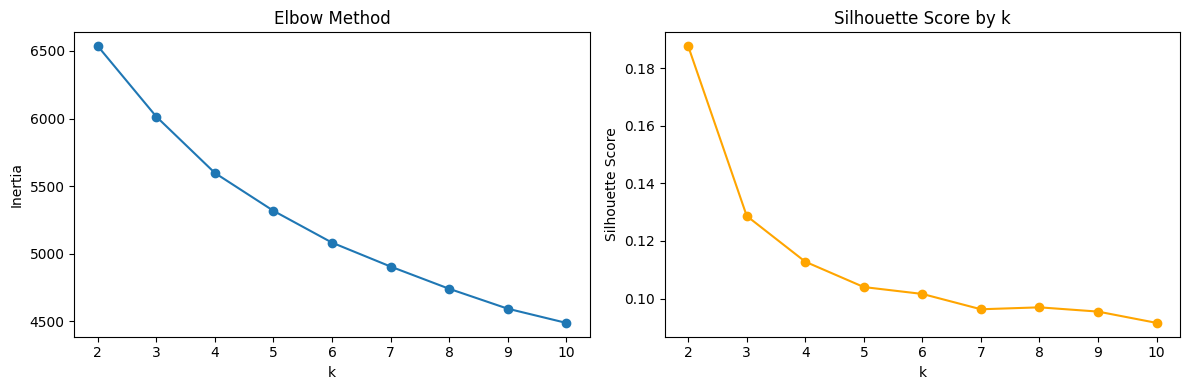

In [52]:
import matplotlib.pyplot as plt

# Plot inertia and silhouette side by side so we can visually spot
# where inertia's improvement starts to flatten (the "elbow"), and
# compare it against where silhouette score peaks
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results['k'], results['inertia'], marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(results['k'], results['silhouette'], marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.show()

In [54]:
from sklearn.mixture import GaussianMixture

In [55]:
N_ARCHETYPES = 6

gmm = GaussianMixture(
    n_components=N_ARCHETYPES,
    covariance_type='diag',
    reg_covar=1e-3,
    random_state=42,
    n_init=10
)
gmm.fit(X_scaled)

probs = gmm.predict_proba(X_scaled)
prob_cols = [f'archetype_{i}_prob' for i in range(N_ARCHETYPES)]
probs_df = pd.DataFrame(probs, columns=prob_cols)
probs_df['batter'] = batter_features['batter'].values
probs_df['top_archetype'] = probs_df[prob_cols].idxmax(axis=1)
probs_df['top_prob'] = probs_df[prob_cols].max(axis=1)

print(probs_df['top_prob'].describe())

# Extract and unscale the 6 archetype centers, same as before
centroids_original_scale = scaler.inverse_transform(gmm.means_)
centroids_df = pd.DataFrame(centroids_original_scale, columns=feature_cols)
centroids_df.index.name = 'archetype'

pd.set_option('display.max_columns', None)
print(centroids_df.round(3))

count    420.000000
mean       0.956745
std        0.097019
min        0.498418
25%        0.971937
50%        0.998376
75%        0.999946
max        1.000000
Name: top_prob, dtype: float64
           k_rate  bb_rate  chase_rate  zone_swing_rate  whiff_rate  \
archetype                                                             
0           0.135    0.075       0.316            0.649       0.158   
1           0.312    0.103       0.302            0.678       0.345   
2           0.184    0.095       0.274            0.636       0.202   
3           0.264    0.077       0.325            0.695       0.294   
4           0.225    0.097       0.305            0.677       0.257   
5           0.208    0.078       0.316            0.672       0.234   

           whiff_rate_fastball  whiff_rate_breaking  whiff_rate_offspeed  \
archetype                                                                  
0                        0.114                0.219                0.215   
1           

In [56]:
# Batters who are poorly explained by ANY archetype will have a LOW
# probability even in their best-fitting group -- these are the ones
# worth eyeballing individually, since they might be genuinely unusual
# hitters the model is struggling to categorize well
poorly_fit = probs_df[probs_df['top_prob'] < 0.6].sort_values('top_prob')
print(f"Batters where even their BEST-fit archetype is under 60% confident: {len(poorly_fit)}")
poorly_fit[['batter', 'top_archetype', 'top_prob']]

Batters where even their BEST-fit archetype is under 60% confident: 10


,batter,top_archetype,top_prob
373,695734,archetype_3_prob,0.498418
335,691011,archetype_5_prob,0.517955
113,662139,archetype_2_prob,0.521929
181,668930,archetype_2_prob,0.531002
412,807713,archetype_5_prob,0.541577
36,596146,archetype_3_prob,0.547289
246,677870,archetype_2_prob,0.573905
364,694497,archetype_3_prob,0.581335
174,668709,archetype_3_prob,0.594655
106,660162,archetype_1_prob,0.594902


In [57]:
from pybaseball import playerid_reverse_lookup

# For each archetype, grab the 5 batters the model is MOST confident
# belong there -- these are the clearest, purest examples to sanity-check
top_examples = (
    probs_df.sort_values('top_prob', ascending=False)
    .groupby('top_archetype')
    .head(5)
    .sort_values(['top_archetype', 'top_prob'], ascending=[True, False])
)

# playerid_reverse_lookup takes a list of MLBAM IDs (the 'batter' column
# IS the MLBAM ID) and returns a table including real names
batter_ids = top_examples['batter'].tolist()
id_lookup = playerid_reverse_lookup(batter_ids, key_type='mlbam')

# Merge names back onto our top examples table
id_lookup['full_name'] = id_lookup['name_first'] + ' ' + id_lookup['name_last']
named_examples = top_examples.merge(
    id_lookup[['key_mlbam', 'full_name']],
    left_on='batter', right_on='key_mlbam', how='left'
)

print(named_examples[['top_archetype', 'full_name', 'top_prob']].to_string(index=False))

Gathering player lookup table. This may take a moment.
   top_archetype         full_name  top_prob
archetype_0_prob  chandler simpson  1.000000
archetype_0_prob       steven kwan  1.000000
archetype_0_prob       luis arráez  1.000000
archetype_0_prob       sal frelick  1.000000
archetype_0_prob     javier sanoja  1.000000
archetype_1_prob munetaka murakami  1.000000
archetype_1_prob     gabriel arias  1.000000
archetype_1_prob   esmerlyn valdez  1.000000
archetype_1_prob        oneil cruz  1.000000
archetype_1_prob     spencer jones  1.000000
archetype_2_prob    gabriel moreno  1.000000
archetype_2_prob   adley rutschman  0.999999
archetype_2_prob      ryan jeffers  0.999999
archetype_2_prob    chase delauter  0.999998
archetype_2_prob   kevin mcgonigle  0.999993
archetype_3_prob     ryan kreidler  0.999985
archetype_3_prob         joey bart  0.999985
archetype_3_prob    konnor griffin  0.999982
archetype_3_prob     rob refsnyder  0.999981
archetype_3_prob    joey loperfido  0.999965


In [58]:
# Ohtani's MLBAM ID is 660271
ohtani_row = probs_df[probs_df['batter'] == 660271]

if len(ohtani_row) == 0:
    print("Ohtani not found -- likely filtered out by the 100+ PA threshold, or ID mismatch")
else:
    print(ohtani_row[['batter', 'top_archetype', 'top_prob'] + prob_cols].to_string(index=False))

 batter    top_archetype  top_prob  archetype_0_prob  archetype_1_prob  archetype_2_prob  archetype_3_prob  archetype_4_prob  archetype_5_prob
 660271 archetype_1_prob  0.874771      1.145814e-72          0.874771      3.814242e-28      3.612773e-17          0.125229      3.859551e-32
